# Modelado KNN - Predicción de Pólizas No Renovadas

In [5]:
!pip install scikit-learn requests pydantic nest_asyncio pandas category-encoders matplotlib seaborn -q

In [ ]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ( classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay, roc_auc_score, average_precision_score, precision_recall_curve )

## 1. Carga de datos

In [7]:
try:
    df = pd.read_csv('Datos_Final.csv')
    print("Datos cargados exitosamente:")
    print(df.info())
except FileNotFoundError:
    print("Error: El archivo 'datos_final.csv' no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Datos cargados exitosamente:
<class 'pandas.DataFrame'>
RangeIndex: 68967 entries, 0 to 68966
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Compania                  68967 non-null  str    
 1   Liquidador                68967 non-null  str    
 2   Evento                    68967 non-null  str    
 3   Fecha_Aviso_Corredora     68967 non-null  str    
 4   Fecha_Plazo_Cierre        68967 non-null  str    
 5   Nombre_Ramo               68967 non-null  str    
 6   Canal                     68967 non-null  str    
 7   Ciudad_y                  68967 non-null  str    
 8   Director_Comercial        68967 non-null  str    
 9   Total_Prima_Bruta_Moneda  68967 non-null  float64
 10  Total_Prima_Bruta_Peso    68967 non-null  float64
 11  Prima_Neta                68967 non-null  float64
 12  Valor_Cuota               68967 non-null  float64
 13  NO_Renovada               68967 non-null  b

## 2. Análisis de Variables



In [8]:
# Cardinalidad de columnas categóricas
obj_cols = ['Compania', 'Evento', 'Nombre_Ramo', 'Canal',
            'Liquidador', 'Ciudad_y', 'Director_Comercial', 'Linea_Negocio', 'Sucursal']

print("Cardinalidad por columna:")
for col in obj_cols:
    print(f"  {col}: {df[col].nunique()} categorías")

Cardinalidad por columna:
  Compania: 20 categorías
  Evento: 4 categorías
  Nombre_Ramo: 35 categorías
  Canal: 3 categorías
  Liquidador: 47 categorías
  Ciudad_y: 91 categorías
  Director_Comercial: 103 categorías
  Linea_Negocio: 30 categorías
  Sucursal: 10 categorías


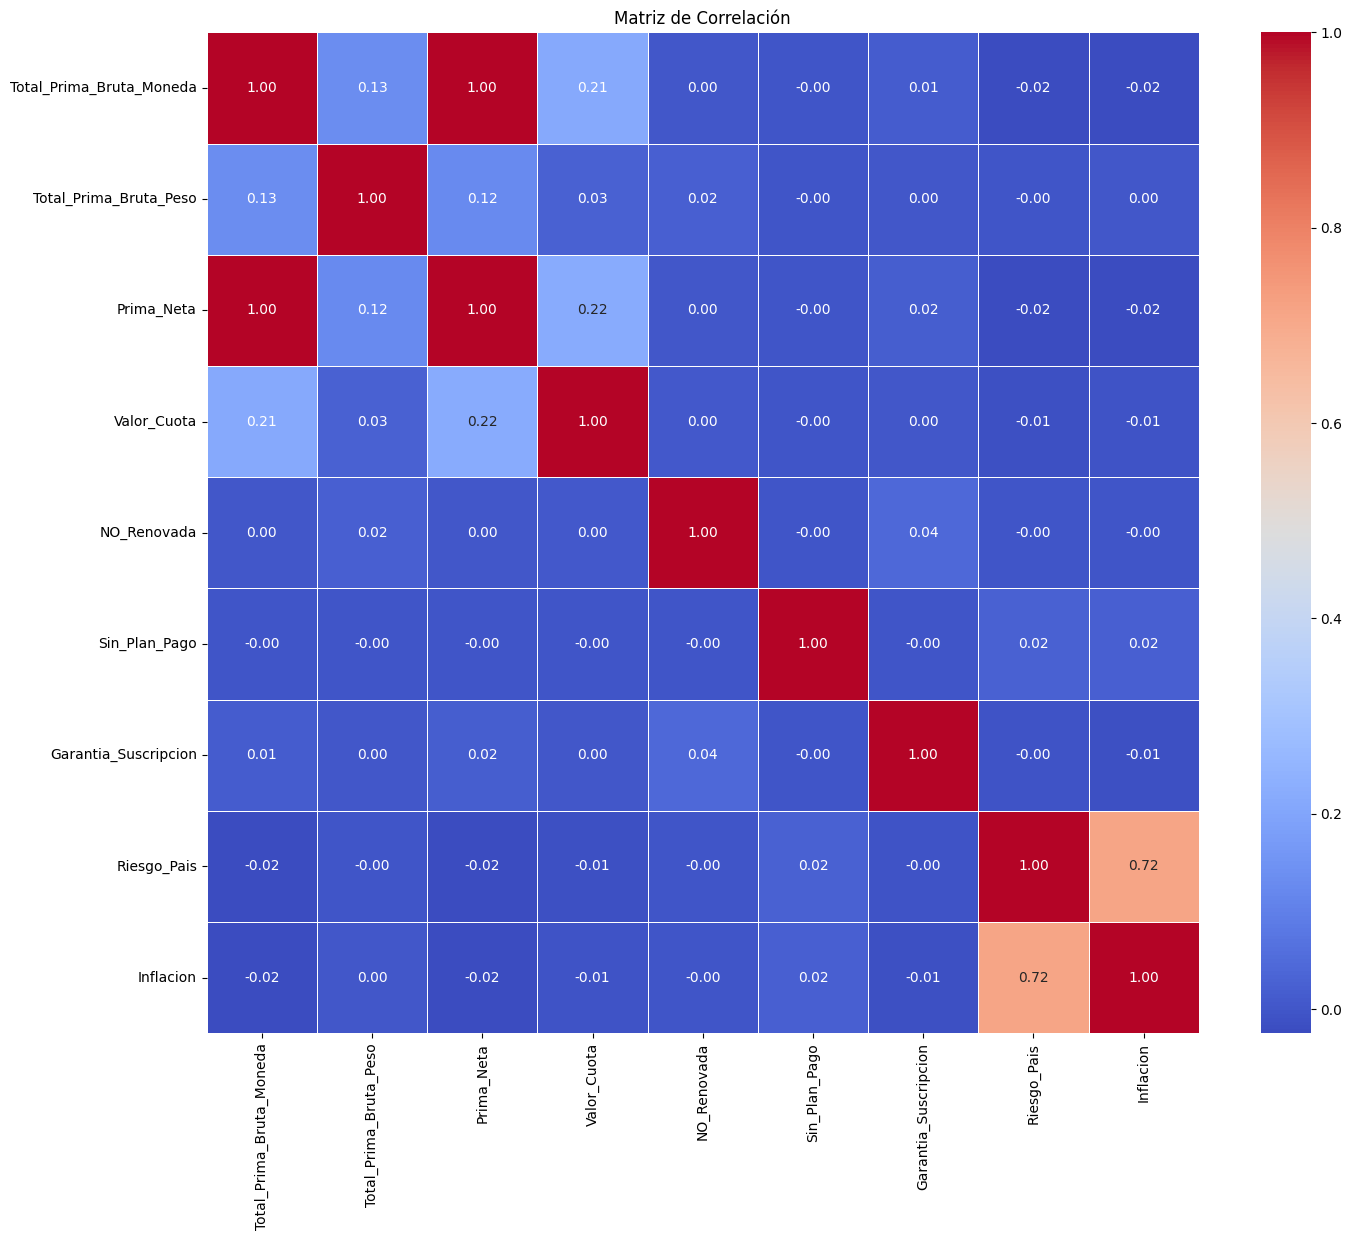

In [9]:
# Matriz de correlación (solo columnas numéricas)
num_df = df.select_dtypes(include=['float64', 'int64', 'bool']).copy()
correlation_matrix = num_df.corr()

plt.figure(figsize=(16, 13))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

## 3. Preprocesamiento

In [10]:
# 1. Separar target
y = df['NO_Renovada'].astype(int)
df_proc = df.drop(columns=['NO_Renovada', 'etiqueta'])

# 2. Eliminar columnas altamente correlacionadas (según matriz de correlación)
df_proc = df_proc.drop(columns=[
    'Total_Prima_Bruta_Moneda',
    'Total_Prima_Bruta_Peso',
    'Inflacion',
    'Fecha_Aviso_Corredora',
    'Fecha_Plazo_Cierre'
])

# 3. Eliminar columnas de alta cardinalidad (generan ruido)
df_proc = df_proc.drop(columns=['Liquidador', 'Director_Comercial'])

# 4. Convertir bools a int
bool_cols = ['Sin_Plan_Pago', 'Garantia_Suscripcion']
df_proc[bool_cols] = df_proc[bool_cols].astype(int)


# 6. OneHotEncoding para columnas de baja/media cardinalidad
ohe_cols = ['Canal', 'Evento', 'Sucursal', 'Compania', 'Linea_Negocio', 'Nombre_Ramo']
df_proc = pd.get_dummies(df_proc, columns=ohe_cols, drop_first=True)

# 7. LabelEncoder para Ciudad_y (91 categorías — OHE sería excesivo)
le_ciudad = LabelEncoder()
df_proc['Ciudad_y'] = le_ciudad.fit_transform(df_proc['Ciudad_y'])

X = df_proc.copy()

COLUMNAS_MODELO = X.columns.tolist()
print(f"Columnas del modelo: {COLUMNAS_MODELO}")

Columnas del modelo: ['Ciudad_y', 'Prima_Neta', 'Valor_Cuota', 'Sin_Plan_Pago', 'Garantia_Suscripcion', 'Riesgo_Pais', 'Canal_EMP', 'Canal_IMP', 'Evento_Lluvias Verano 21', 'Evento_NORMAL', 'Evento_normal', 'Sucursal_AJG Quillota', 'Sucursal_AJG Santiago', 'Sucursal_AJG Viña del Mar', 'Sucursal_Etchepare', 'Sucursal_RKC', 'Sucursal_THB Curicó', 'Sucursal_THB Los Ángeles', 'Sucursal_THB Santiago', 'Sucursal_THB Talca', 'Compania_BCI GENERALES', 'Compania_CHUBB GENERALES', 'Compania_CONSORCIO GENERALES', 'Compania_CONTEMPORA SEGUROS GENERALES', 'Compania_CONTINENTAL GENERALES', 'Compania_EVEREST SEGUROS GENERALES CHILE S.A', 'Compania_FID', 'Compania_HDI GENERALES', 'Compania_HDI SEGUROS (EX LIBERTY)', 'Compania_MAPFRE GENERALES', 'Compania_MAPFRE VIDA', 'Compania_ORION', 'Compania_REALE SEGUROS', 'Compania_RENTA NACIONAL GENERALES', 'Compania_SOUTHBRIDGE', 'Compania_STARR GENERALES', 'Compania_SURA GENERALES', 'Compania_UNNIO', 'Compania_ZURICH GENERALES', 'Linea_Negocio_Affinity Masivo

## 4. Split y Balanceo con SMOTETomek

In [11]:
# Split ANTES del balanceo (stratify mantiene proporción en test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribución antes del balanceo:")
print(f"  Train: {Counter(y_train)}")
print(f"  Test: {Counter(y_test)}")

# Aplicar SMOTETomek SOLO al train
smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train, y_train)
print(f"\nTrain balanceado: {Counter(y_train_bal)}")

Distribución antes del balanceo:
  Train: Counter({0: 55070, 1: 103})
  Test: Counter({0: 13768, 1: 26})

Train balanceado: Counter({0: 55055, 1: 55055})


## 5. Escalado

In [12]:
from sklearn.preprocessing import StandardScaler

# fit solo en train, transform en ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("Escalado completado.")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape:  {X_test_scaled.shape}")

Escalado completado.
  X_train_scaled shape: (110110, 102)
  X_test_scaled shape:  (13794, 102)


# Pruebas de Modelos

K= 1 → F1: 0.5385
K= 3 → F1: 0.5660
K= 5 → F1: 0.5085
K= 7 → F1: 0.4918
K= 9 → F1: 0.4839

K óptimo: 3 con F1=0.5660


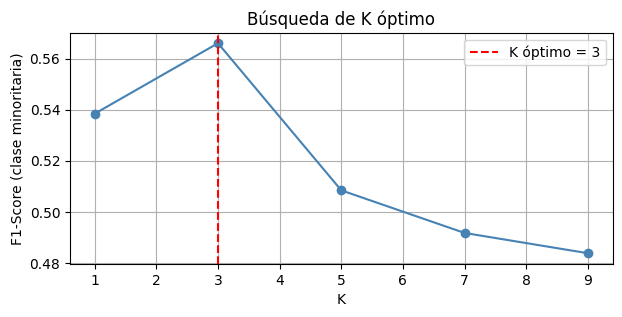

In [13]:
k_range = range(1, 11, 2)
f1_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train_scaled, y_train_bal)
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    f1_scores.append(f1)
    print(f"K={k:2d} → F1: {f1:.4f}")

k_optimo = list(k_range)[f1_scores.index(max(f1_scores))]
print(f"\nK óptimo: {k_optimo} con F1={max(f1_scores):.4f}")

plt.figure(figsize=(7, 3))
plt.plot(k_range, f1_scores, marker='o', color='steelblue')
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
plt.xlabel('K')
plt.ylabel('F1-Score (clase minoritaria)')
plt.title('Búsqueda de K óptimo')
plt.legend()
plt.grid(True)
plt.show()


  KNN
              precision    recall  f1-score   support

    Renovada       1.00      1.00      1.00     13768
 No Renovada       0.56      0.58      0.57        26

    accuracy                           1.00     13794
   macro avg       0.78      0.79      0.78     13794
weighted avg       1.00      1.00      1.00     13794


Roc score: 0.8069520180574801
Precisión promedio 0.402230402663202



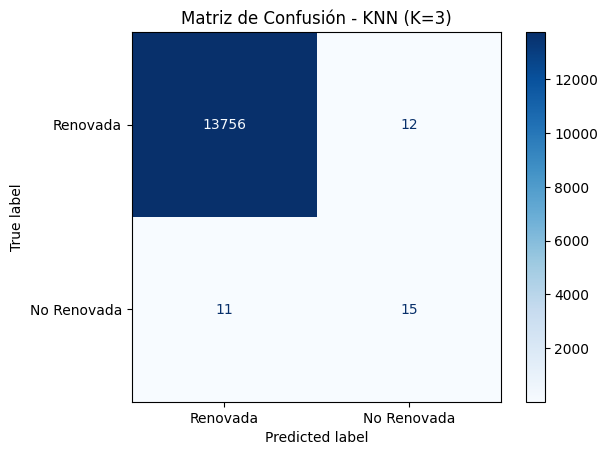


  Random Forest
              precision    recall  f1-score   support

    Renovada       1.00      1.00      1.00     13768
 No Renovada       0.80      0.62      0.70        26

    accuracy                           1.00     13794
   macro avg       0.90      0.81      0.85     13794
weighted avg       1.00      1.00      1.00     13794


Roc score: 0.9767213829169089
Precisión promedio 0.6966402494504417



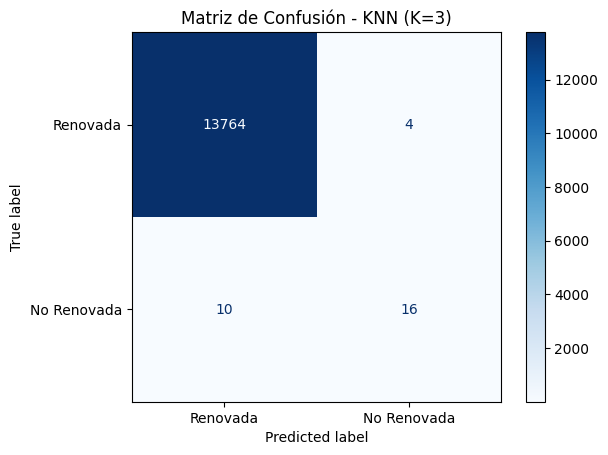


  XGBoost
              precision    recall  f1-score   support

    Renovada       1.00      1.00      1.00     13768
 No Renovada       0.70      0.62      0.65        26

    accuracy                           1.00     13794
   macro avg       0.85      0.81      0.83     13794
weighted avg       1.00      1.00      1.00     13794


Roc score: 0.9625972153935547
Precisión promedio 0.6625771010564654



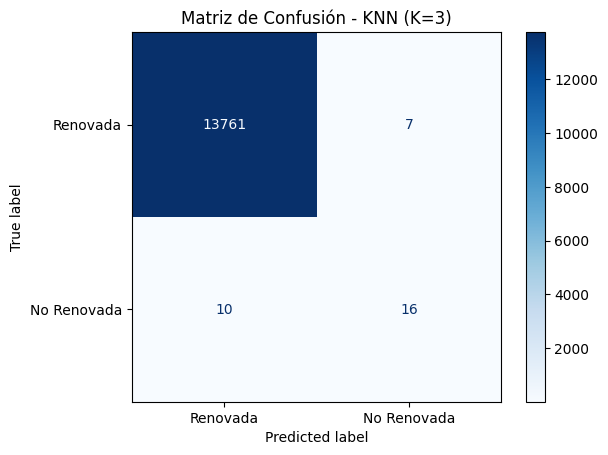


  Gradient Boosting
              precision    recall  f1-score   support

    Renovada       1.00      0.99      0.99     13768
 No Renovada       0.11      0.77      0.20        26

    accuracy                           0.99     13794
   macro avg       0.56      0.88      0.60     13794
weighted avg       1.00      0.99      0.99     13794


Roc score: 0.9736303244982794
Precisión promedio 0.510512654865447



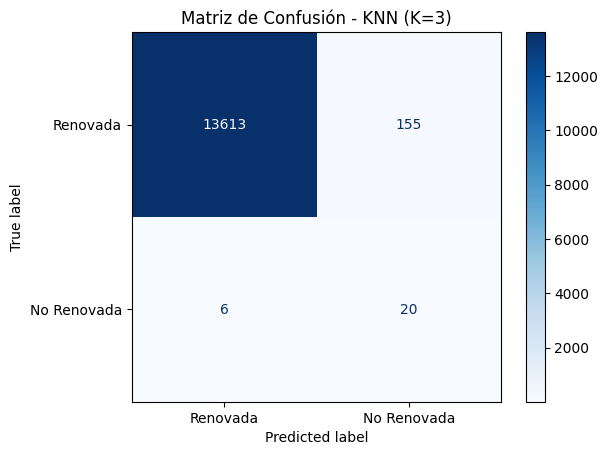

In [14]:
modelos = {
    'KNN': KNeighborsClassifier(
        n_neighbors=k_optimo,
        metric='euclidean',
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',   # penaliza más los errores en clase minoritaria
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train_bal)
    y_pred = modelo.predict(X_test_scaled)
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Renovada', 'No Renovada']))

    print()
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    print(f'Roc score: {roc_auc_score(y_test, y_prob)}')
    print(f'Precisión promedio {average_precision_score(y_test, y_prob)}')
    print()
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Renovada', 'No Renovada'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - KNN (K={k_optimo})')
    plt.show()


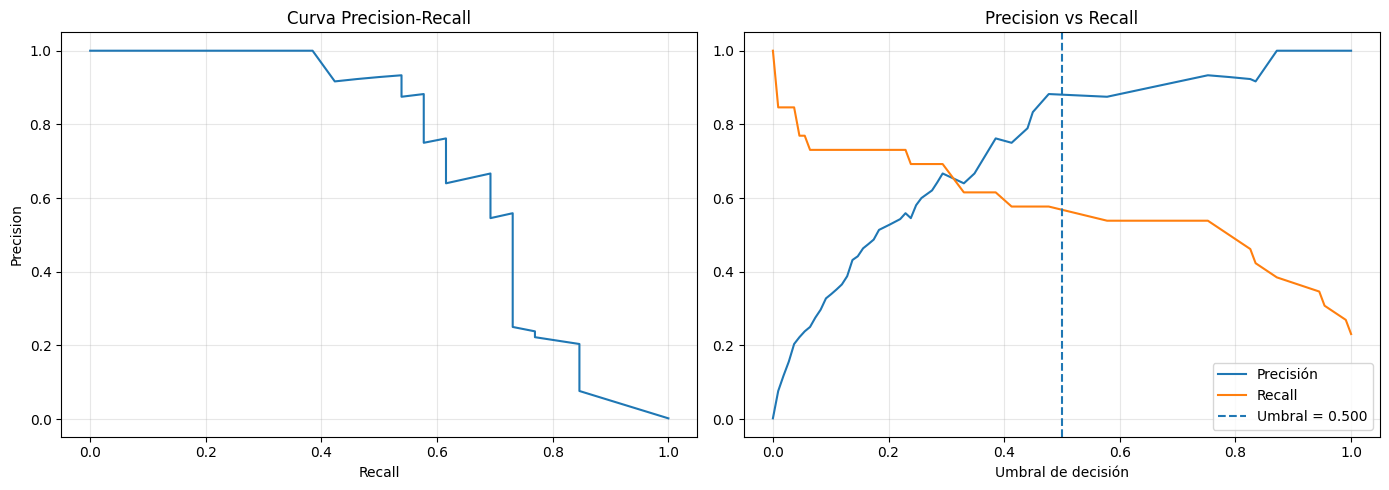


✅ Modelo guardado | Umbral: 0.5000


In [15]:
# SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# BALANCEO 
smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train_scaled, y_train_bal)

# MODELO 
modelo = BalancedRandomForestClassifier(
    n_estimators=109,
    sampling_strategy='auto',
    replacement=True,
    random_state=42,
    n_jobs=-1
)


# ── ENTRENAMIENTO ────────────────────────────────────────────
modelo.fit(X_train_bal, y_train_bal)

proba = modelo.predict_proba(X_test_scaled)[:, 1]
umbral = 0.5
# ── GRÁFICAS ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva Precision-Recall
prec, rec, thr = precision_recall_curve(y_test, proba)

axes[0].plot(rec, prec)

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].grid(True, alpha=0.3)

# Precision vs Threshold
axes[1].plot(thr, prec[:-1], label='Precisión')
axes[1].plot(thr, rec[:-1], label='Recall')

axes[1].axvline(
    umbral,
    linestyle='--',
    label=f'Umbral = {umbral:.3f}'
)

axes[1].set_xlabel('Umbral de decisión')
axes[1].set_title('Precision vs Recall')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── GUARDAR MODELO ───────────────────────────────────────────
bundle = {
    'modelo': modelo,
    'scaler': scaler,
    'le_ciudad': le_ciudad,
    'columnas': COLUMNAS_MODELO,
    'umbral_optimo': umbral,
    'ohe_cols': ohe_cols,
    'recall_objetivo': 0.85,
}

joblib.dump(bundle, 'polizas_brf_model.pkl')

print(f"\n✅ Modelo guardado | Umbral: {umbral:.4f}")

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def graficar_matriz_confusion(modelo, X_test_scaled, y_test, umbral, nombre_modelo):
    """
    Grafica la matriz de confusión usando el umbral optimizado.
    """
    proba = modelo.predict_proba(X_test_scaled)[:, 1]
    y_pred = (proba >= umbral).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Renovada', 'No Renovada']
    )
    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False,
        values_format='d'
    )

    ax.set_title(
        f'Matriz de Confusión — {nombre_modelo}\n'
        f'(Umbral = {umbral:.4f})',
        fontsize=12, pad=12
    )
    plt.tight_layout()
    plt.show()

    return cm

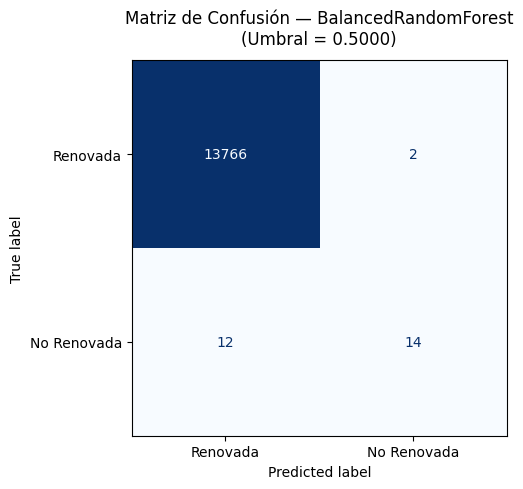

In [17]:
cm = graficar_matriz_confusion(
    modelo    =  modelo,
    X_test_scaled = X_test_scaled,
    y_test    = y_test,
    umbral    =  umbral,
    nombre_modelo = 'BalancedRandomForest'
)

## 6. Búsqueda del K óptimo

In [18]:

# CARGAR EL BUNDLE 
PKL_PATH = 'polizas_brf_model.pkl'   

bundle        = joblib.load(PKL_PATH)
modelo        = bundle['modelo']
scaler        = bundle['scaler']
le_ciudad     = bundle['le_ciudad']
COLUMNAS      = bundle['columnas']
UMBRAL        = bundle['umbral_optimo']
OHE_COLS      = bundle['ohe_cols']

print(f"✅ Modelo cargado correctamente")
print(f"   Tipo:     {type(modelo).__name__}")
print(f"   Umbral:   {UMBRAL:.4f}")
print(f"   Features: {len(COLUMNAS)}")

# FUNCIÓN DE PREPROCESAMIENTO 
def preprocesar(fila: dict) -> np.ndarray:
    """
    Convierte un dict con los datos de una póliza al vector que espera el modelo.

    Campos requeridos:
        Prima Neta, Valor_Cuota, Dias_Entre_Aviso_Cierre,
        Riesgo_Pais, Sin_Plan_Pago (bool), 
        Garantia_Suscripcion (bool), Compania, 
        Evento, Nombre_Ramo, Canal,
        Ciudad_y, Linea_Negocio, Sucursal
    """

    base = {
        'Prima_Neta':              fila['Prima_Neta'],
        'Valor_Cuota':             fila['Valor_Cuota'],
        'Dias_Entre_Aviso_Cierre': fila['Dias_Entre_Aviso_Cierre'],
        'Sin_Plan_Pago':           int(fila['Sin_Plan_Pago']),
        'Garantia_Suscripcion':    int(fila['Garantia_Suscripcion']),
        'Riesgo_Pais':             fila['Riesgo_Pais'] 
    }

    # Ciudad con LabelEncoder; desconocida → 0
    ciudad = fila['Ciudad_y']
    base['Ciudad_y'] = (
        int(le_ciudad.transform([ciudad])[0])
        if ciudad in le_ciudad.classes_ else 0
    )

    # Armar DataFrame con todas las columnas del modelo
    row = pd.DataFrame([base])
    for col in COLUMNAS:
        if col not in row.columns:
            row[col] = 0

    # Activar dummies OHE
    mapa = {
        'Canal':         fila['Canal'],
        'Evento':        fila['Evento'],
        'Sucursal':      fila['Sucursal'],
        'Compania':      fila['Compania'],
        'Linea_Negocio': fila['Linea_Negocio'],
        'Nombre_Ramo':   fila['Nombre_Ramo'],
    }
    for prefijo, valor in mapa.items():
        col_ohe = f"{prefijo}_{valor}"
        if col_ohe in COLUMNAS:
            row[col_ohe] = 1

    return scaler.transform(row[COLUMNAS])


# PREDICCIÓN INDIVIDUAL 
def predecir(fila: dict, umbral: float = UMBRAL) -> dict:
    """Predice una sola póliza y devuelve resultado + probabilidad."""
    X = preprocesar(fila)
    prob_no_renueva = float(modelo.predict_proba(X)[0][1])
    prediccion = int(prob_no_renueva >= umbral)
    return {
        'resultado':        'No Renovada' if prediccion else 'Renovada',
        'prob_no_renovada': round(prob_no_renueva * 100, 2),
        'umbral_usado':     round(umbral, 4),
    }


# PREDICCIÓN POR LOTE (DataFrame o lista de dicts) 
def predecir_lote(datos, umbral: float = UMBRAL) -> pd.DataFrame:
    """
    datos: lista de dicts o DataFrame con las mismas columnas que predecir().
    Devuelve un DataFrame con columnas: resultado, prob_no_renovada.
    """
    if isinstance(datos, pd.DataFrame):
        registros = datos.to_dict(orient='records')
    else:
        registros = datos

    resultados = [predecir(r, umbral) for r in registros]
    return pd.DataFrame(resultados)


# EVALUACIÓN COMPLETA CON DATOS ETIQUETADOS 
def evaluar(X_test_raw: pd.DataFrame, y_test: pd.Series,
            umbral: float = UMBRAL, mostrar_curva: bool = True):
    """
    Evalúa el modelo sobre un conjunto de test ya procesado y escalado.
    X_test_raw: DataFrame con las columnas originales (sin escalar).
    y_test:     Serie con 0=Renovada, 1=No Renovada.
    """
    # Preprocesar cada fila
    X_scaled = np.vstack([preprocesar(r) for r in X_test_raw.to_dict('records')])
    y_prob   = modelo.predict_proba(X_scaled)[:, 1]
    y_pred   = (y_prob >= umbral).astype(int)

    print(f"\n{'='*55}")
    print(f"  Evaluación — umbral = {umbral:.4f}")
    print('='*55)
    print(classification_report(y_test, y_pred,
                                target_names=['Renovada', 'No Renovada']))
    print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_test, y_prob):.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2 if mostrar_curva else 1,
                            figsize=(13 if mostrar_curva else 5, 4))
    ax_cm = axes[0] if mostrar_curva else axes

    ConfusionMatrixDisplay(cm, display_labels=['Renovada', 'No Renovada'])\
        .plot(ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title(f'Matriz de confusión (umbral={umbral:.3f})')

    if mostrar_curva:
        prec, rec, thr = precision_recall_curve(y_test, y_prob)
        axes[1].plot(rec, prec, color='steelblue', lw=2)
        # Marcar el umbral actual
        idx = np.argmin(np.abs(thr - umbral))
        axes[1].scatter(rec[idx], prec[idx], color='red', zorder=5,
                        label=f'Umbral actual ({umbral:.3f})')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precisión')
        axes[1].set_title('Curva Precision-Recall')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return y_prob

# EJEMPLO DE USO
if __name__ == '__main__':

    # Predicción individual 
    poliza_ejemplo = {
        "Prima_Neta":              84011.0,    
        "Valor_Cuota":             77757.0,
        "Dias_Entre_Aviso_Cierre": 90.0,
        "Sin_Plan_Pago":           False,
        "Garantia_Suscripcion":    False,
        "Compania":                "EVEREST SEGUROS GENERALES CHILE S.A",
        "Evento":                  "NORMAL",
        "Nombre_Ramo":             "R. Civil General",
        "Canal":                   "DIR",
        "Ciudad_y":                "Santiago",
        "Linea_Negocio":           "Empresas",
        "Riesgo_Pais":              1044.0,
        "Sucursal":                "THB Santiago",
    }

    print("\n── Predicción individual ──")
    resultado = predecir(poliza_ejemplo)
    print(f"  Resultado:        {resultado['resultado']}")
    print(f"  Prob No Renovada: {resultado['prob_no_renovada']}%")
    print(f"  Umbral usado:     {resultado['umbral_usado']}")

✅ Modelo cargado correctamente
   Tipo:     BalancedRandomForestClassifier
   Umbral:   0.5000
   Features: 102

── Predicción individual ──
  Resultado:        No Renovada
  Prob No Renovada: 53.21%
  Umbral usado:     0.5


In [19]:
# CARGAR CSV 
ruta = "polizas_ajustadas.csv"

try:
    df = pd.read_csv(ruta, sep=",", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(ruta, sep=",", encoding="latin1")

# ── CONVERTIR BOOLEANOS 
mapa_bool = {
    "VERDADERO": 1,
    "FALSO": 0,
}

for col in ["Sin_Plan_Pago", "Garantia_Suscripcion"]:

    # Convertir a string y limpiar espacios
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Mapear
    df[col] = df[col].map(mapa_bool)

    # Rellenar nulos
    df[col] = df[col].fillna(0).astype(int)

print("Datos cargados correctamente")
print()

print(df[[
    "Prima_Neta",
    "Dias_Entre_Aviso_Cierre",
    "Sin_Plan_Pago",
    "Garantia_Suscripcion"
]].head())

Datos cargados correctamente

   Prima_Neta  Dias_Entre_Aviso_Cierre  Sin_Plan_Pago  Garantia_Suscripcion
0    82718478                       60              0                     0
1    37851225                       60              0                     0
2    37851225                       60              0                     0
3    37851225                       60              0                     0
4    37851225                       60              0                     0


In [20]:
resultados = []
for i, row in df.iterrows():

    row_dict = row.to_dict()
    res = predecir(row_dict)
    resultados.append({
        "fila":             i,
        "Prima_Neta":       row["Prima_Neta"],
        "Dias_Aviso_Cierre": row["Dias_Entre_Aviso_Cierre"],
        "resultado":        res["resultado"],
        "prob_no_renovada": res["prob_no_renovada"],
        "umbral_usado":     res["umbral_usado"],
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

# 5. Resumen
total        = len(df_resultados)
no_renuevan  = (df_resultados["resultado"] == "No Renovada").sum()
renuevan     = (df_resultados["resultado"] == "Renovada").sum()

print(f"\n── Resumen ──")
print(f"  Total pólizas:  {total}")
print(f"  Renuevan:       {renuevan}  ({renuevan/total*100:.1f}%)")
print(f"  No renuevan:    {no_renuevan}  ({no_renuevan/total*100:.1f}%)")
print(f"  Prob promedio no renovar: {df_resultados['prob_no_renovada'].mean():.2f}%")

 fila  Prima_Neta  Dias_Aviso_Cierre   resultado  prob_no_renovada  umbral_usado
    0    82718478                 60    Renovada             48.62           0.5
    1    37851225                 60 No Renovada             55.05           0.5
    2    37851225                 60 No Renovada             55.05           0.5
    3    37851225                 60 No Renovada             55.05           0.5
    4    37851225                 60 No Renovada             55.05           0.5
    5    37851225                 60 No Renovada             55.05           0.5
    6     2466014                 60 No Renovada             55.96           0.5
    7     2466014                 60 No Renovada             55.96           0.5
    8     2466014                 60 No Renovada             55.96           0.5
    9     2466014                 60 No Renovada             55.96           0.5
   10     2466014                 60 No Renovada             55.96           0.5
   11     2466014           